**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: 19/06/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()


## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [3]:
# ---- Experiment settings ----
TAG = "only-essays-v1"
SCHEMA_DATE = "230726"

# ---- Paths ----
FILE_NAME = "dataset_annealing_iacs.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
# FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"

PROCESS = "annealing_iacs"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["initial_diameter", "purity", "iacs", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.1 Schema data

In [4]:
# Schema dataset. Mark essay rows EXPLICITLY (used later for weight_col).
df_raw_schema = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA))
df_schema = df_raw_schema[FEATURES + [TARGET]].dropna()
df_schema["is_essay"] = True
df_schema


,initial_diameter,purity,iacs,temperature,time,iacs_final,is_essay
0,1.900000,99.9000,88.260,623.0,30.0,88.350000,True
1,1.900000,99.9000,88.260,623.0,60.0,88.655000,True
2,1.900000,99.9000,88.260,623.0,90.0,88.800000,True
4,2.160000,99.9000,99.825,573.0,30.0,102.340000,True
5,2.182333,99.9000,99.390,573.0,30.0,102.230000,True
7,2.182333,99.9000,99.390,588.0,30.0,101.346667,True
8,2.191700,99.9000,99.230,573.0,30.0,101.355000,True
9,2.196300,99.9000,98.720,573.0,30.0,101.480000,True
11,1.200000,99.9000,97.710,523.0,30.0,100.290000,True
12,1.200000,99.9000,97.710,523.0,60.0,100.420000,True


## 2.2 Literature data

In [5]:
# Raw CSV.
df_raw = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME))
df_raw

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98
...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,60,~2000,~67.4
127,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,120,~2500,~68.2
128,Al–Mn–Mg alloy,~99.5,250,~35,423,60,~400,~38
129,Al–Mn–Mg alloy,~99.5,250,~35,523,60,~800,~43


In [6]:
# # Cast to float, label material elements, mark rows where ratios are valid.
# df_float = proc.df_to_float(
#     df_raw, drop_cols=["DOI"], ignore_columns=["material"]
# )
# df_labeled = feng.label_element(df_float).drop_duplicates()
# df_with_masks = feng.add_ratio_mask_column(
#     feng.add_ratio_mask_column(df_labeled, "grain_size"),
#     "iacs",
# )

# # Keep only copper rows and the schema columns.
# mask_cu = df_with_masks.has_Cu == True
# df_lit = df_with_masks[mask_cu]
# df_lit = df_lit[FEATURES + [TARGET]]
# df_lit["is_essay"] = False

# assert df_lit[FEATURES + [TARGET]].isna().sum().sum() == 0, "NaNs in inputs"
# print(f"Dataset: {df_lit.shape}")
# df_lit.head()


## 2.3 Concat dataset

In [7]:
# df = pd.concat([df_schema, df_lit], ignore_index=True)
df = df_schema.reset_index(drop=True).copy()
df["weight_col"] = np.where(df["is_essay"], WEIGHT_ON_ESSAY_ROWS, 1.0)

# # Optional shared fold column: the SAME partition is passed to AutoGluon
# # (groups=) and H2O (fold_column=) so OOF comparisons use identical folds.
# if USE_SHARED_FOLDS:
#     df = feng.add_stratified_fold_column(
#         df, n_folds=NUM_BAG_FOLDS_A, seed=FOLD_SEED,
#     )

# df

df

,initial_diameter,purity,iacs,temperature,time,iacs_final,is_essay,weight_col
0,1.900000,99.9000,88.260,623.0,30.0,88.350000,True,1.0
1,1.900000,99.9000,88.260,623.0,60.0,88.655000,True,1.0
2,1.900000,99.9000,88.260,623.0,90.0,88.800000,True,1.0
3,2.160000,99.9000,99.825,573.0,30.0,102.340000,True,1.0
4,2.182333,99.9000,99.390,573.0,30.0,102.230000,True,1.0
5,2.182333,99.9000,99.390,588.0,30.0,101.346667,True,1.0
6,2.191700,99.9000,99.230,573.0,30.0,101.355000,True,1.0
7,2.196300,99.9000,98.720,573.0,30.0,101.480000,True,1.0
8,1.200000,99.9000,97.710,523.0,30.0,100.290000,True,1.0
9,1.200000,99.9000,97.710,523.0,60.0,100.420000,True,1.0


## 2.4 Validation data

In [8]:
# # ---- Validation data ----
# df_val = proc.load_validation_data_chimie_paris(
#     path=os.path.join(varv.PATHS.data_processed, FILE_NAME_VALIDATION_DATA)
# )


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [9]:
df.head(10)

,initial_diameter,purity,iacs,temperature,time,iacs_final,is_essay,weight_col
0,1.900000,99.9,88.260,623.0,30.0,88.350000,True,1.0
1,1.900000,99.9,88.260,623.0,60.0,88.655000,True,1.0
2,1.900000,99.9,88.260,623.0,90.0,88.800000,True,1.0
3,2.160000,99.9,99.825,573.0,30.0,102.340000,True,1.0
4,2.182333,99.9,99.390,573.0,30.0,102.230000,True,1.0
5,2.182333,99.9,99.390,588.0,30.0,101.346667,True,1.0
6,2.191700,99.9,99.230,573.0,30.0,101.355000,True,1.0
7,2.196300,99.9,98.720,573.0,30.0,101.480000,True,1.0
8,1.200000,99.9,97.710,523.0,30.0,100.290000,True,1.0
9,1.200000,99.9,97.710,523.0,60.0,100.420000,True,1.0


In [10]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.83 GB / 31.57 GB (28.0%)
Disk Space Avail:   733.67 GB / 932.08 GB (78.7%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\only-essays-v1\model_a"
Train Data Rows:    34
Train Data Columns: 5
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (104.865, 88.35, 100.98446, 4.20125)
	If 'regression' is not

In [11]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-1.129570,root_mean_squared_error,0.032040,0.497150,0.000000,0.008675,2,True,10
1,RandomForestMSE_BAG_L1,-1.129570,root_mean_squared_error,0.032040,0.488475,0.032040,0.488475,1,True,3
2,ExtraTreesMSE_BAG_L1,-1.233877,root_mean_squared_error,0.034108,0.374701,0.034108,0.374701,1,True,5
3,CatBoost_BAG_L1,-2.200905,root_mean_squared_error,0.038526,2.775205,0.038526,2.775205,1,True,4
4,XGBoost_BAG_L1,-2.226403,root_mean_squared_error,0.009191,0.847232,0.009191,0.847232,1,True,7
5,LightGBMLarge_BAG_L1,-2.502760,root_mean_squared_error,0.000000,1.074940,0.000000,1.074940,1,True,9
6,NeuralNetTorch_BAG_L1,-2.953080,root_mean_squared_error,0.033271,7.376945,0.033271,7.376945,1,True,8
7,LightGBM_BAG_L1,-4.415203,root_mean_squared_error,0.001520,1.324694,0.001520,1.324694,1,True,2
8,LightGBMXT_BAG_L1,-4.415203,root_mean_squared_error,0.001528,0.426943,0.001528,0.426943,1,True,1
9,NeuralNetFastAI_BAG_L1,-4.480545,root_mean_squared_error,0.033465,7.118160,0.033465,7.118160,1,True,6


In [12]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-1.129570,root_mean_squared_error,0.032040,0.497150,0.000000,0.008675,2,True,10
1,RandomForestMSE_BAG_L1,-1.129570,root_mean_squared_error,0.032040,0.488475,0.032040,0.488475,1,True,3
2,ExtraTreesMSE_BAG_L1,-1.233877,root_mean_squared_error,0.034108,0.374701,0.034108,0.374701,1,True,5
3,CatBoost_BAG_L1,-2.200905,root_mean_squared_error,0.038526,2.775205,0.038526,2.775205,1,True,4
4,XGBoost_BAG_L1,-2.226403,root_mean_squared_error,0.009191,0.847232,0.009191,0.847232,1,True,7
5,LightGBMLarge_BAG_L1,-2.502760,root_mean_squared_error,0.000000,1.074940,0.000000,1.074940,1,True,9
6,NeuralNetTorch_BAG_L1,-2.953080,root_mean_squared_error,0.033271,7.376945,0.033271,7.376945,1,True,8
7,LightGBM_BAG_L1,-4.415203,root_mean_squared_error,0.001520,1.324694,0.001520,1.324694,1,True,2
8,LightGBMXT_BAG_L1,-4.415203,root_mean_squared_error,0.001528,0.426943,0.001528,0.426943,1,True,1
9,NeuralNetFastAI_BAG_L1,-4.480545,root_mean_squared_error,0.033465,7.118160,0.033465,7.118160,1,True,6


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [13]:
import h2o
from h2o.automl import H2OAutoML

h2o.init(nthreads=-1, max_mem_size="4G")

h2o_cols = FEATURES + [TARGET, "weight_col"]
if USE_SHARED_FOLDS:
    h2o_cols.append("fold_id")
train_h2o = h2o.H2OFrame(df[h2o_cols])
train_h2o[TARGET] = train_h2o[TARGET].asnumeric()
if USE_SHARED_FOLDS:
    # fold_column must be categorical on the H2O side.
    train_h2o["fold_id"] = train_h2o["fold_id"].asfactor()

aml_kwargs = dict(
    max_runtime_secs=TIME_LIMIT_A,
    keep_cross_validation_predictions=True,
    exclude_algos=["DeepLearning"],
    sort_metric="RMSE",
    seed=42,
)
if not USE_SHARED_FOLDS:
    aml_kwargs["nfolds"] = NUM_BAG_FOLDS_A  # nfolds is ignored/conflicting with fold_column

aml_h2o = H2OAutoML(**aml_kwargs)

train_kwargs = dict(x=FEATURES, y=TARGET, training_frame=train_h2o,
                    weights_column="weight_col")
if USE_SHARED_FOLDS:
    train_kwargs["fold_column"] = "fold_id"

aml_h2o.train(**train_kwargs)

aml_h2o.leaderboard.head(10)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\fmfoa\AppData\Local\Temp\tmp9ezak9e3
  JVM stdout: C:\Users\fmfoa\AppData\Local\Temp\tmp9ezak9e3\h2o_fmfoa_started_from_python.out
  JVM stderr: C:\Users\fmfoa\AppData\Local\Temp\tmp9ezak9e3\h2o_fmfoa_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 11 days
H2O_cluster_name:,H2O_from_python_fmfoa_lpbgd9
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.983 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
18:36:44.22: AutoML: XGBoost is not available; skipping it.


18:36:44.542: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 34.0.

█
18:36:45.324: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.

██
18:36:45.476: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.

██
18:36:46.19: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the m

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_lr_annealing_selection_AutoML_1_20260723_183643_select_model,0.842367,0.709583,0.580946,0.00822918,0.709583
GBM_grid_1_AutoML_1_20260723_183643_model_886,0.847594,0.718415,0.570772,0.00826849,0.718415
GBM_grid_1_AutoML_1_20260723_183643_model_624,0.855724,0.732264,0.639268,0.0083621,0.732264
GBM_grid_1_AutoML_1_20260723_183643_model_466,0.872536,0.761318,0.592904,0.00849269,0.761318
GBM_grid_1_AutoML_1_20260723_183643_model_791,0.879313,0.773192,0.634937,0.00856201,0.773192
GBM_grid_1_AutoML_1_20260723_183643_model_1375,0.89481,0.800685,0.631647,0.00871741,0.800685
StackedEnsemble_AllModels_5_AutoML_1_20260723_183643,0.898688,0.807641,0.662087,0.00879924,0.807641
GBM_grid_1_AutoML_1_20260723_183643_model_1398,0.907313,0.823218,0.633617,0.00881872,0.823218
GBM_grid_1_AutoML_1_20260723_183643_model_64,0.92157,0.849291,0.609757,0.00896846,0.849291
GBM_grid_1_AutoML_1_20260723_183643_model_1372,0.921891,0.849884,0.647023,0.00898073,0.849884


In [14]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [15]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(34,)  any NaN? False


## 4.1 fast check on big residuals

In [16]:
residuals_oof.head(10)

0   -2.132559
1   -1.746123
2   -1.668254
3   -0.506458
4    0.763531
5   -0.702894
6   -0.614231
7   -0.097530
8   -0.305093
9   -0.153273
Name: iacs_final, dtype: float64

In [17]:
df[residuals_oof.abs() > 2]

,initial_diameter,purity,iacs,temperature,time,iacs_final,is_essay,weight_col
0,1.9,99.9000,88.26,623.0,30.0,88.350,True,1.0
25,1.2,99.9800,102.70,573.0,60.0,100.785,True,1.0
31,2.0,99.9558,97.40,573.0,30.0,98.960,True,1.0


In [18]:
mu_oof[residuals_oof.abs() > 2]

0      90.482559
25    103.375053
31    101.775948
Name: iacs_final, dtype: float32

## 4.2 Recovering weights 

In [19]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 34)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [20]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000000  (OK)

Non-zero weights:
  RandomForestMSE_BAG_L1          1.0000


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [21]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    34.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: iacs_final, dtype: float64

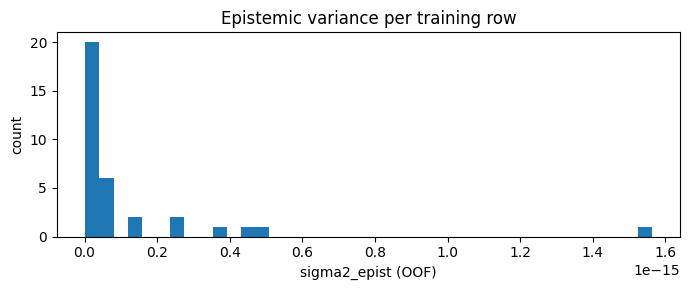

In [22]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [23]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    34.000000
mean      1.063101
std       1.502861
min       0.018822
25%       0.281868
50%       0.616249
75%       1.135899
max       6.255150
Name: iacs_final, dtype: float64

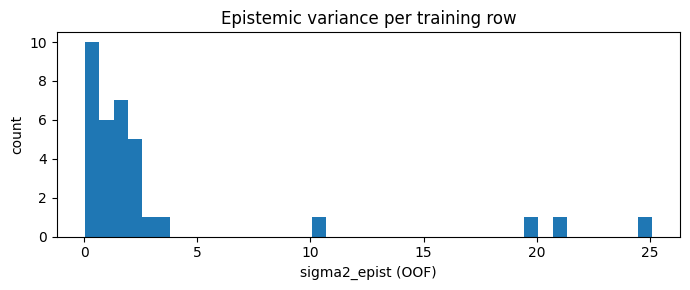

In [24]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [25]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 34
  n_truncated          = 0
  pct_truncated        = 0.0
  r_tilde_sq_min       = 9.757997095506726e-06
  r_tilde_sq_max       = 7.929560721498856
  r_tilde_sq_mean      = 1.2759285741037074
  r_tilde_sq_median    = 0.34197252867603145


In [26]:
r_tilde_sq

array([4.54780876e+00, 3.04894569e+00, 2.78307171e+00, 2.56500146e-01,
       5.82979877e-01, 4.94059760e-01, 3.77279294e-01, 9.51208280e-03,
       9.30816004e-02, 2.34925221e-02, 7.20360831e-02, 2.92385941e-01,
       2.01899573e-02, 1.70440802e-02, 1.55132323e-01, 5.17826233e-03,
       1.53939271e-02, 1.84248908e-01, 4.29507670e-01, 1.06659639e+00,
       9.75799710e-06, 3.16790888e-03, 3.06665764e-01, 5.08256556e-05,
       2.54578736e+00, 6.70837664e+00, 2.58028220e+00, 9.78873760e-01,
       1.72554939e+00, 2.07018335e-03, 1.69136899e+00, 7.92956072e+00,
       3.25055656e+00, 1.18480647e+00])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [27]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.36 GB / 31.57 GB (20.1%)
Disk Space Avail:   733.53 GB / 932.08 GB (78.7%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\only-essays-v1\model_b"
Train Data Rows:    34
Train Data Columns: 5
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (2.0705977657081602, -11.439861164097762, -1.83775, 3.208

In [28]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-1.941095,root_mean_squared_error,0.033002,9.683596,0.000000,0.006992,2,True,10
1,LightGBMLarge_BAG_L1,-2.151207,root_mean_squared_error,0.005998,1.314704,0.005998,1.314704,1,True,9
2,CatBoost_BAG_L1,-2.413328,root_mean_squared_error,0.006005,19.212823,0.006005,19.212823,1,True,4
3,NeuralNetTorch_BAG_L1,-2.422895,root_mean_squared_error,0.027004,8.361900,0.027004,8.361900,1,True,8
4,XGBoost_BAG_L1,-2.566890,root_mean_squared_error,0.008009,0.756320,0.008009,0.756320,1,True,7
5,ExtraTreesMSE_BAG_L1,-2.589454,root_mean_squared_error,0.034014,0.390484,0.034014,0.390484,1,True,5
6,RandomForestMSE_BAG_L1,-2.674610,root_mean_squared_error,0.050887,0.498629,0.050887,0.498629,1,True,3
7,LightGBMXT_BAG_L1,-3.299773,root_mean_squared_error,0.001999,1.174262,0.001999,1.174262,1,True,1
8,LightGBM_BAG_L1,-3.299773,root_mean_squared_error,0.004597,1.213778,0.004597,1.213778,1,True,2
9,NeuralNetFastAI_BAG_L1,-3.301113,root_mean_squared_error,0.027002,6.361758,0.027002,6.361758,1,True,6


In [29]:
predictor_b.predict_oof()  

0    -0.606497
1    -1.023352
2    -1.766955
3    -1.740222
4    -1.746436
5    -1.422232
6    -3.235399
7    -1.479854
8    -2.333256
9    -3.357028
10   -3.976470
11   -1.904527
12   -3.737885
13   -3.265032
14   -1.795270
15   -2.278789
16   -2.786637
17   -1.694982
18   -3.386966
19   -0.830351
20   -6.621304
21   -3.606225
22   -3.028542
23   -7.667228
24    0.165470
25    0.052738
26   -1.665191
27   -0.510735
28    0.027271
29   -1.626928
30   -0.106577
31    0.309474
32    0.689197
33   -0.746015
Name: log_r_tilde_sq, dtype: float32

In [30]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    "iacs": df["iacs"],
    "iacs_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,iacs,iacs_final
0,-2.132559,-0.606497,5.020548e-16,88.260,88.350000
1,-1.746123,-1.023352,4.468446e-16,88.260,88.655000
2,-1.668254,-1.766955,3.702411e-16,88.260,88.800000
3,-0.506458,-1.740222,2.469937e-16,99.825,102.340000
4,0.763531,-1.746436,4.299665e-18,99.390,102.230000
5,-0.702894,-1.422232,4.886199e-18,99.390,101.346667
6,-0.614231,-3.235399,2.198638e-17,99.230,101.355000
7,-0.097530,-1.479854,2.033036e-17,98.720,101.480000
8,-0.305093,-2.333256,1.870995e-18,97.710,100.290000
9,-0.153273,-3.357028,3.029436e-18,97.710,100.420000


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [31]:
df[TARGET].var()

np.float64(17.650510391403156)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [32]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.323529,-0.176471
1,0.80,0.470588,-0.329412
2,0.90,0.794118,-0.105882
3,0.95,0.911765,-0.038235


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [33]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 1.2812

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.352941,-0.147059
1,0.80,0.794118,-0.005882
2,0.90,0.911765,0.011765
3,0.95,0.970588,0.020588


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [34]:
c_opt
weights

array([0.00000000e+00, 3.01683849e-18, 1.00000000e+00, 2.53102455e-18,
       5.78756660e-16, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00])

In [35]:
len(base_model_names)
len(weights)

9

In [36]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df_val, # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df_val, #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

NameError: name 'df_val' is not defined

In [39]:
# ---- Target-agnostic point prediction from a plain dict ----
single = modl.predict_target(
    predictor_a,
    {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
)
print(f"Predicted {TARGET}: {single[0]:.3f}")

Predicted iacs_final: 89.236


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [ ]:
df.head(5)

,purity,iacs,temperature,time,iacs_final,is_essay,weight_col,fold_id
0,99.9,88.260,623.0,30.0,88.350,True,1.0,3
1,99.9,88.260,623.0,60.0,88.655,True,1.0,0
2,99.9,88.260,623.0,90.0,88.800,True,1.0,2
3,99.9,99.825,573.0,30.0,102.340,True,1.0,0
4,99.9,99.390,573.0,30.0,102.230,True,1.0,4


In [40]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,89.131935,4.547658e-16,1.595025,2.618183,1.618080,89.131935,1.000000,89.131935,1.618080,0.000000e+00
1,89.260323,4.343196e-16,1.098450,1.803070,1.342784,89.260323,1.000000,89.260323,1.342784,0.000000e+00
2,89.383888,4.262682e-16,0.735662,1.207565,1.098893,89.383888,1.001359,89.383888,1.098893,0.000000e+00
3,102.532455,4.071522e-17,0.176505,0.289727,0.538263,102.532455,1.000000,102.532450,0.538250,2.277875e-06
4,101.990761,3.532242e-18,0.176505,0.289727,0.538263,101.990761,1.000000,101.990761,0.538263,1.131139e-08


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [41]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_iacs\only-essays-v1\artifacts.pkl


In [42]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_iacs\only-essays-v1\global_config.txt


In [43]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


                         model      rmse       mae      mape        r2
0  AutoGluon (Model A, leader)  1.129570  0.830812  0.839219  0.925521
1          H2O AutoML (leader)  0.842368  0.580946  0.575050  0.958580
Saved to: ../../models/annealing_iacs\only-essays-v1


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [44]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: iacs_final
Features: ['initial_diameter', 'purity', 'iacs', 'temperature', 'time']


In [46]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,89.131935,4.547658e-16,1.595025,2.618183,1.618080,89.131935,1.000000,89.131935,1.618080,0.000000e+00
1,89.260323,4.343196e-16,1.098450,1.803070,1.342784,89.260323,1.000000,89.260323,1.342784,0.000000e+00
2,89.383888,4.262682e-16,0.735662,1.207565,1.098893,89.383888,1.001359,89.383888,1.098893,0.000000e+00
3,102.532455,4.071522e-17,0.176505,0.289727,0.538263,102.532455,1.000000,102.532450,0.538250,2.277875e-06
4,101.990761,3.532242e-18,0.176505,0.289727,0.538263,101.990761,1.000000,101.990761,0.538263,1.131139e-08


In [48]:
# ---- 4) Target-agnostic quick prediction from a plain dict ----
# Works for any predictor/target via modl.predict_target (features inferred
# from the predictor when not passed explicitly).
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

Predicted iacs_final: 89.236


In [49]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
